In [33]:
import numpy as np
import pandas as pf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense , Flatten ,MaxPooling2D,Conv2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist

In [24]:
#Load_data
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [25]:
#Normalize dataset
x_train = x_train/255.0
x_test = x_test/255.0

In [26]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [27]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

In [28]:
#CNN model
model = Sequential([
    Conv2D(32,(3,3),activation = 'relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 32ms/step - accuracy: 0.9587 - loss: 0.1348 - val_accuracy: 0.9863 - val_loss: 0.0428
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9861 - loss: 0.0450 - val_accuracy: 0.9887 - val_loss: 0.0346
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9904 - loss: 0.0299 - val_accuracy: 0.9887 - val_loss: 0.0337
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9931 - loss: 0.0226 - val_accuracy: 0.9906 - val_loss: 0.0309
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 90s 35ms/step - accuracy: 0.9944 - loss: 0.0169 - val_accuracy: 0.9905 - val_loss: 0.0303


In [31]:
predict=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [54]:
uploaded =files.upload()

Saving Screenshot 2026-05-15 195635.png to Screenshot 2026-05-15 195635.png


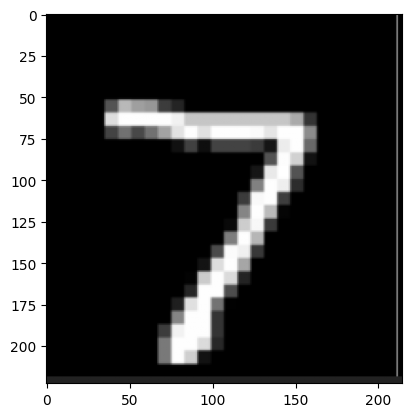

In [57]:
img=cv2.imread("/content/Screenshot 2026-05-15 193233 (1).png",cv2.IMREAD_REDUCED_GRAYSCALE_2)
plt.imshow(img,cmap='gray')
plt.show()


In [58]:
img=cv2.resize(img,(28,28))
img=img/255.0
img=img.reshape(1,28,28,1)
pred=model.predict(img)
predicted_digit=np.argmax(pred)
print("Predicted Digit:",predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Digit: 7
